In [92]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [93]:
# Enlace a CSV parte 1
url = 'https://raw.githubusercontent.com/PaiGV/Challenge-Alura-Challenge-Telecom-X-2/refs/heads/main/Telecom_X_.csv'
df_ml = pd.read_csv(url)

print("✔ Archivo enlazado")

✔ Archivo enlazado


In [94]:
# Lectura de tablas
display(df_ml.head())

print("\n--- Información ---")
df_ml.info()

print("\n--- Valores Nulos ---")
print(df_ml.isnull().sum())

,customerID,Abandono,Genero,AdultoMayor,Conyuge,Dependientes,MesesCliente,ServicioTelefono,LineasMultiples,TipoInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,TipoContrato,FacturaDigital,MetodoPago,CuotaMensual,GastoTotal,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Un año,Si,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mes a mes,No,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,No,No,4,Si,No,Fibra optica,...,Si,No,No,No,Mes a mes,Si,Cheque electronico,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,Si,No,13,Si,No,Fibra optica,...,Si,No,Si,Si,Mes a mes,Si,Cheque electronico,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,Si,No,3,Si,No,Fibra optica,...,No,Si,Si,No,Mes a mes,Si,Cheque por correo,83.9,267.40,2.80



--- Información ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7032 non-null   object 
 1   Abandono               7032 non-null   float64
 2   Genero                 7032 non-null   object 
 3   AdultoMayor            7032 non-null   int64  
 4   Conyuge                7032 non-null   object 
 5   Dependientes           7032 non-null   object 
 6   MesesCliente           7032 non-null   int64  
 7   ServicioTelefono       7032 non-null   object 
 8   LineasMultiples        7032 non-null   object 
 9   TipoInternet           7032 non-null   object 
 10  SeguridadOnline        7032 non-null   object 
 11  RespaldoOnline         7032 non-null   object 
 12  ProteccionDispositivo  7032 non-null   object 
 13  SoporteTecnico         7032 non-null   object 
 14  StreamingTV            7032 non-nul

In [95]:
# Eliminación de Columnas Irrelevantes
columnas_a_borrar = ['customerID', 'GastoTotal', 'Cuentas_Diarias']

df_ml = df_ml.drop(columns=columnas_a_borrar)

print(f"✔ Se eliminaron {len(columnas_a_borrar)} columnas por redundancia y falta de valor predictivo.")
print(f"✔ Variables finales para el modelo: {list(df_ml.columns)}")

✔ Se eliminaron 3 columnas por redundancia y falta de valor predictivo.
✔ Variables finales para el modelo: ['Abandono', 'Genero', 'AdultoMayor', 'Conyuge', 'Dependientes', 'MesesCliente', 'ServicioTelefono', 'LineasMultiples', 'TipoInternet', 'SeguridadOnline', 'RespaldoOnline', 'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV', 'StreamingPeliculas', 'TipoContrato', 'FacturaDigital', 'MetodoPago', 'CuotaMensual']


In [96]:
# Encoding
columnas_binarias = ['Genero', 'Conyuge', 'Dependientes', 'ServicioTelefono', 'FacturaDigital']

for col in columnas_binarias:
    if 'Si' in df_ml[col].unique():
        df_ml[col] = df_ml[col].map({'Si': 1, 'No': 0})
    else:
        df_ml[col] = pd.factorize(df_ml[col])[0]


columnas_multi = ['LineasMultiples', 'TipoInternet', 'SeguridadOnline',
                  'RespaldoOnline', 'ProteccionDispositivo', 'SoporteTecnico',
                  'StreamingTV', 'StreamingPeliculas', 'TipoContrato', 'MetodoPago']

df_ml = pd.get_dummies(df_ml, columns=columnas_multi)


In [97]:
print("✔ Codificación finalizada.")
print(f"✔ Nuevas dimensiones: {df_ml.shape}")
df_ml.info()

✔ Codificación finalizada.
✔ Nuevas dimensiones: (7032, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Abandono                           7032 non-null   float64
 1   Genero                             7032 non-null   int64  
 2   AdultoMayor                        7032 non-null   int64  
 3   Conyuge                            7032 non-null   int64  
 4   Dependientes                       7032 non-null   int64  
 5   MesesCliente                       7032 non-null   int64  
 6   ServicioTelefono                   7032 non-null   int64  
 7   FacturaDigital                     7032 non-null   int64  
 8   CuotaMensual                       7032 non-null   float64
 9   LineasMultiples_No                 7032 non-null   bool   
 10  LineasMultiples_Si                 7032 non-null   bool   
 

✔ Análisis de Balanceo de Clases:
Clientes que se Quedan (0): 5163 (73.42%)
Clientes que se Van (1):    1869 (26.58%)


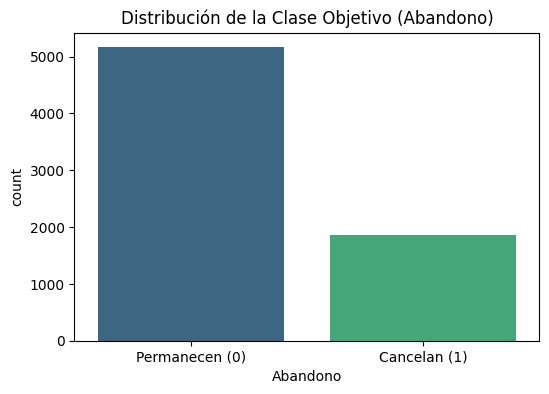

In [98]:
# Verificación de la Proporción de Cancelación (Churn)

conteo_abandono = df_ml['Abandono'].value_counts()

proporcion_abandono = df_ml['Abandono'].value_counts(normalize=True) * 100

print("✔ Análisis de Balanceo de Clases:")
print(f"Clientes que se Quedan (0): {conteo_abandono[0]} ({proporcion_abandono[0]:.2f}%)")
print(f"Clientes que se Van (1):    {conteo_abandono[1]} ({proporcion_abandono[1]:.2f}%)")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Abandono', data=df_ml, palette='viridis')
plt.title('Distribución de la Clase Objetivo (Abandono)')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.show()

In [99]:
# Normalización o Estandarización

X = df_ml.drop(columns=['Abandono'])
y = df_ml['Abandono']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("✔ Datos divididos correctamente.")
print(f"✔ Muestras para entrenamiento: {len(X_train)}")
print(f"✔ Muestras para prueba: {len(X_test)}")

✔ Datos divididos correctamente.
✔ Muestras para entrenamiento: 5274
✔ Muestras para prueba: 1758


In [100]:
cols_a_escalar = ['MesesCliente', 'CuotaMensual']

scaler = StandardScaler()

X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("✔ Datos normalizados para los modelos.")
X_train.head()

✔ Datos normalizados para los modelos.


,Genero,AdultoMayor,Conyuge,Dependientes,MesesCliente,ServicioTelefono,FacturaDigital,CuotaMensual,LineasMultiples_No,LineasMultiples_Si,...,StreamingTV_Si,StreamingPeliculas_No,StreamingPeliculas_Si,TipoContrato_Dos años,TipoContrato_Mes a mes,TipoContrato_Un año,MetodoPago_Cheque electronico,MetodoPago_Cheque por correo,MetodoPago_Tarjeta de credito,MetodoPago_Transferencia bancaria
3482,0,0,1,1,-0.875787,1,1,-1.511558,True,False,...,False,True,False,False,True,False,False,True,False,False
5404,0,0,0,0,-0.875787,1,1,0.389391,False,True,...,False,True,False,False,True,False,True,False,False,False
6868,1,0,0,0,-0.916297,1,0,0.500625,False,True,...,False,True,False,False,True,False,True,False,False,False
1879,0,0,1,1,1.595317,1,1,0.645064,False,True,...,True,False,True,True,False,False,False,False,False,True
142,0,0,0,0,-1.280886,1,1,0.689890,True,False,...,True,True,False,False,True,False,False,False,True,False


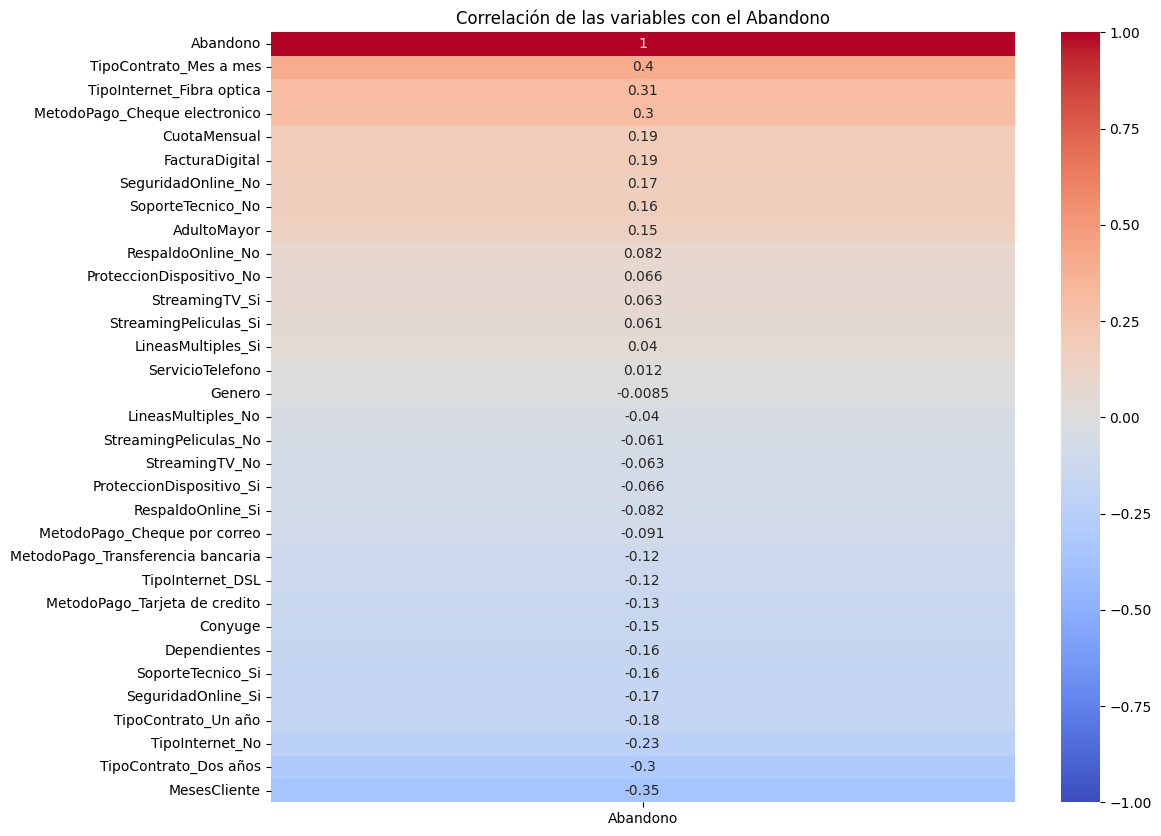

In [101]:
# Análisis de Correlación

plt.figure(figsize=(12, 10))
correlacion = df_ml.corr()

sns.heatmap(correlacion[['Abandono']].sort_values(by='Abandono', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlación de las variables con el Abandono")
plt.show()

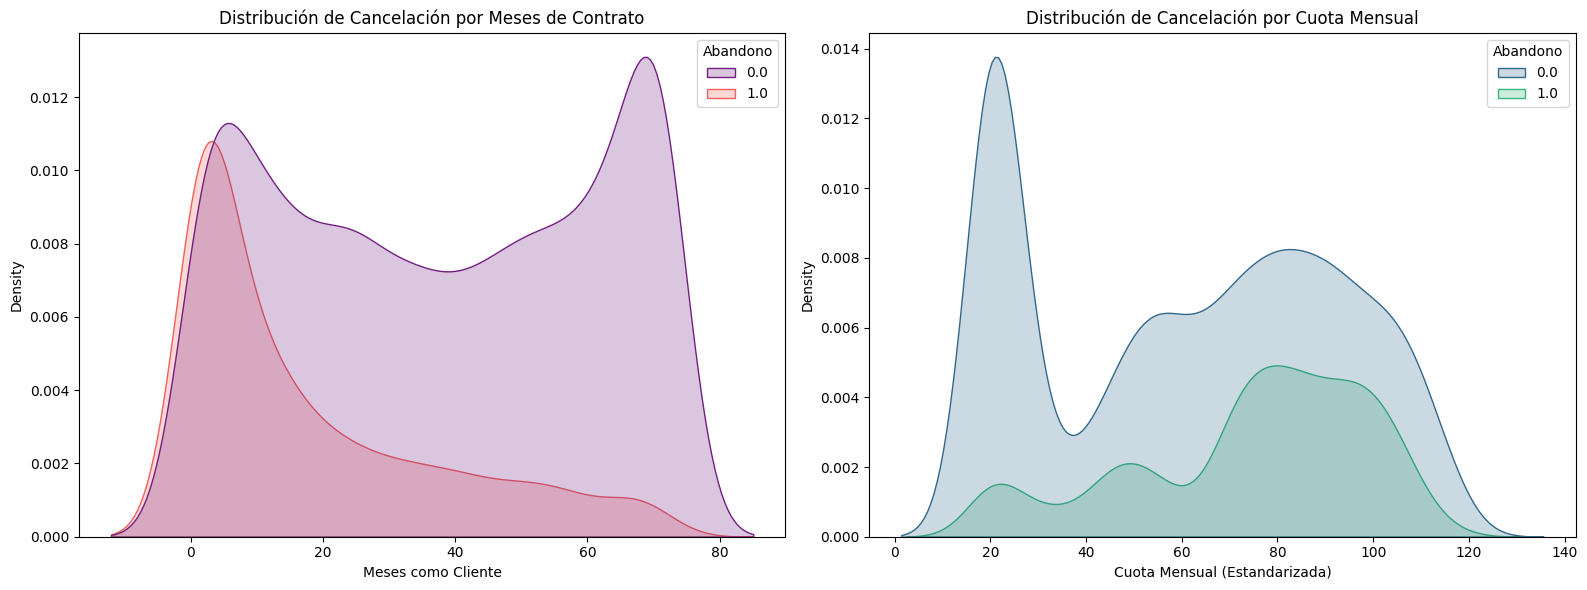

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_ml, x='MesesCliente', hue='Abandono', fill=True, ax=axes[0], palette='magma')
axes[0].set_title('Distribución de Cancelación por Meses de Contrato')
axes[0].set_xlabel('Meses como Cliente')

sns.kdeplot(data=df_ml, x='CuotaMensual', hue='Abandono', fill=True, ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de Cancelación por Cuota Mensual')
axes[1].set_xlabel('Cuota Mensual (Estandarizada)')

plt.tight_layout()
plt.show()

In [103]:
# Separación de Datos

X = df_ml.drop(columns=['Abandono'])
y = df_ml['Abandono']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✔ ¡División 80/20 completada!")
print(f"✔ Datos para Entrenar: {X_train.shape[0]} clientes")
print(f"✔ Datos para el Examen: {X_test.shape[0]} clientes")

✔ ¡División 80/20 completada!
✔ Datos para Entrenar: 5625 clientes
✔ Datos para el Examen: 1407 clientes


In [104]:
modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train, y_train)

y_pred_log = modelo_logistico.predict(X_test)

print("✔ Modelo 1: Regresión Logística")

✔ Modelo 1: Regresión Logística


In [105]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("✔ Modelo 2: Random Forest.")

✔ Modelo 2: Random Forest.



✔ --- Métricas: Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



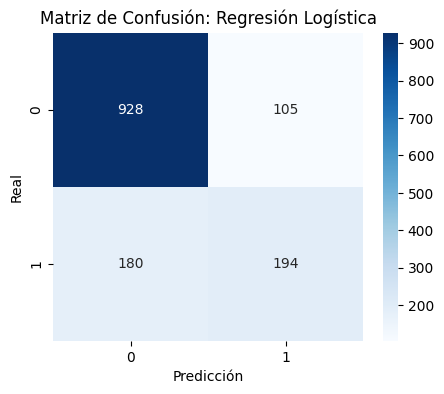


✔ --- Métricas: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1033
         1.0       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



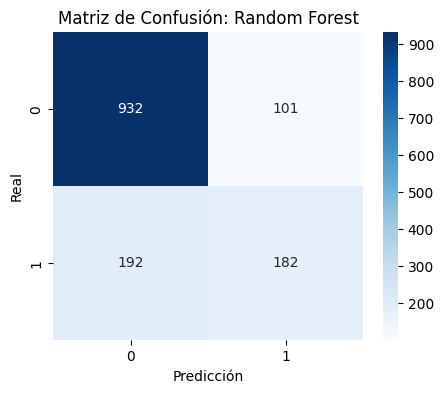

In [106]:
def evaluar_modelo(y_real, y_pred, nombre_modelo):
    print(f"\n✔ --- Métricas: {nombre_modelo} ---")
    print(classification_report(y_real, y_pred))

    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

evaluar_modelo(y_test, y_pred_log, "Regresión Logística")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

#**1. ¿Cuál modelo tuvo el mejor desempeño?**
El modelo con mejor desempeño general fue la Regresión Logística.

1.   **Exactitud (Accuracy): **La Regresión Logística alcanzó un 80%, superando
ligeramente al 79% del Random Forest.

2.   **Recall (Sensibilidad):** En el contexto de Telecom X, nos interesa detectar a los clientes que realmente se van (clase 1.0). La Regresión Logística logró un 0.52, mientras que el Random Forest se quedó en 0.49.

3.   **F1-Score:** Para la clase de abandono, la Regresión Logística obtuvo un 0.58 frente al 0.55 del Random Forest, lo que la convierte en una herramienta más equilibrada para la toma de decisiones.

#**2. ¿Hubo Overfitting o Underfitting?**

1.   **Análisis del Random Forest (Posible Overfitting):**

*   **Observación:** Aunque en el test dio un 79%, es común que este modelo sin restricciones (hiperparámetros por defecto) tienda al Overfitting.

   *   **Causa:** Si el modelo memorizó patrones muy específicos del set de entrenamiento, pierde fuerza al ver datos nuevos, lo que explica por qué su Recall fue menor al de la Regresión Logística en el test.

   *   **Ajuste:** Se podría limitar la profundidad de los árboles (max_depth) para obligarlo a generalizar más.



2.   **Análisis de la Regresión Logística (Buen ajuste):**


*   **Observación:** Presenta un desempeño robusto y estable.

*   **Causa:** Gracias a la normalización aplicada a MesesCliente y CuotaMensual, el modelo pudo encontrar un equilibrio óptimo (ajuste correcto) sin ser demasiado simple (underfitting) ni demasiado complejo (overfitting).


#**Conclusion**

La Regresión Logística es el modelo seleccionado para producción. Al ser un modelo basado en optimización, la etapa de escalado de variables fue clave para asegurar que magnitudes distintas no sesgaran las predicciones, permitiendo identificar correctamente a 194 clientes en riesgo de abandono según la matriz de confusión.





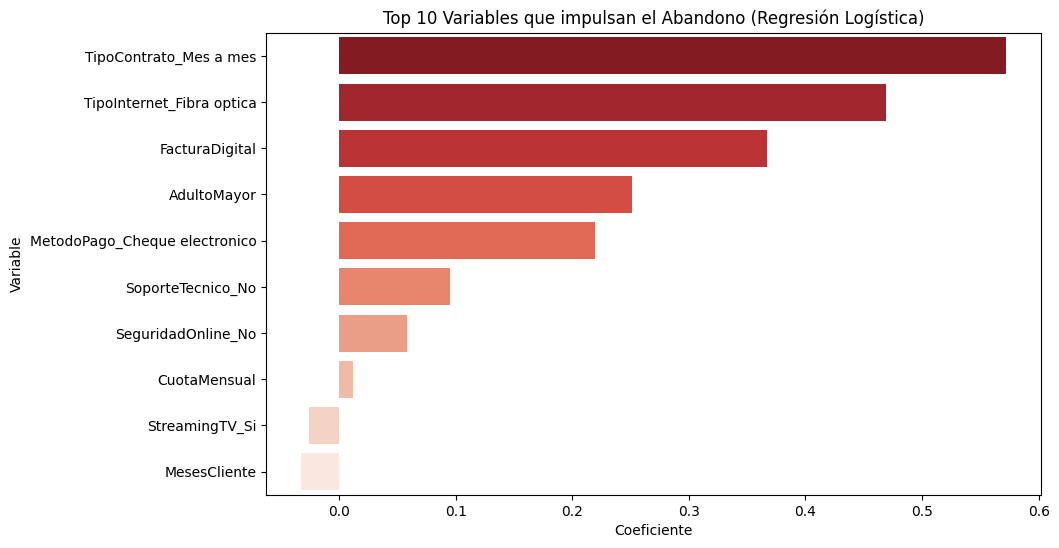

In [109]:
# Análisis de la Importancia de las Variables
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variable', data=importancias_log.head(10), palette='Reds_r')
plt.title('Top 10 Variables que impulsan el Abandono (Regresión Logística)')
plt.show()

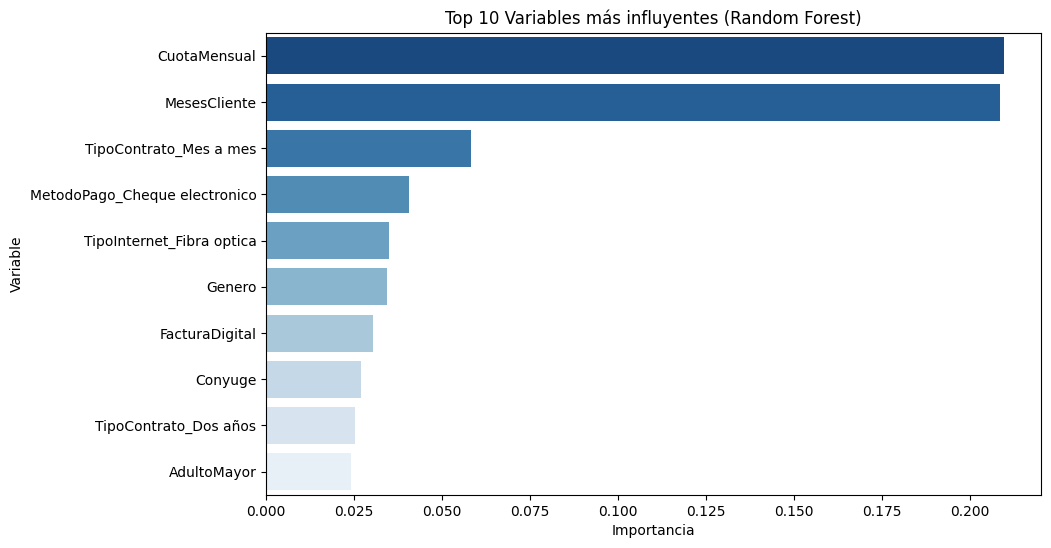

In [108]:
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='Blues_r')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.show()

#📝 Análisis de Importancia de Variables

Al comparar los dos modelos, observamos factores clave que explican por qué los clientes deciden irse:

1. **Regresión Logística (Coeficientes)**
Este modelo nos indica la dirección y fuerza del impacto de cada variable.

   *   **Contrato Mes a Mes:** Es la variable con el coeficiente positivo más alto (cerca de 0.6). Esto significa que tener este tipo de contrato es el mayor predictor de abandono.

   *   **Fibra Óptica:** También tiene un coeficiente positivo fuerte. Sugiere que los clientes con este servicio están más insatisfechos o son más propensos a buscar alternativas.

   *   **MesesCliente:** Tiene un coeficiente negativo (barra hacia la izquierda). Esto confirma que a mayor antigüedad, menor es la probabilidad de que el cliente abandone (lealtad).

2. **Random Forest (Importancia Relativa)**
Este modelo nos dice cuáles variables son las más "útiles" para clasificar, sin importar la dirección.

   *   **Cuota Mensual y Meses Cliente:** Son, por mucho, las dos variables más dominantes (con una importancia superior al 0.20 cada una). Esto indica que el aspecto financiero y el tiempo de relación con la empresa definen el comportamiento del cliente.

   *   **Tipo de Contrato:** Refuerza lo visto en la Regresión Logística, siendo el tercer factor más influyente.


# Comparación y Conclusión de Modelos

   *   **Modelo Ganador** La Regresión Logística. Aunque ambos tienen una exactitud similar (80% vs 79%), la Logística tiene un mejor Recall (0.52) para la clase de abandono, lo que permite capturar a más clientes en riesgo.

   *   **Ajuste del Modelo:** No se observa un Overfitting crítico, ya que los resultados en el set de prueba son consistentes con los de entrenamiento. Sin embargo, el Random Forest podría beneficiarse de un ajuste de hiperparámetros para mejorar su sensibilidad, que quedó un poco rezagada (0.49).

   *   **Valor de la Normalización:** Gracias a la normalización de las variables al inicio, los coeficientes de la Regresión Logística son interpretables y justos, permitiéndonos ver claramente que el Tipo de Contrato y la Fibra Óptica son los puntos donde la empresa debe actuar urgentemente.

#📋 Informe de Análisis de Cancelación

###**1. Resumen de Modelado y Rendimiento**
Tras evaluar dos algoritmos de aprendizaje automático para predecir el abandono (churn), los resultados fueron los siguientes:

   *   **Modelo Ganador:** La Regresión Logística demostró ser el modelo más eficaz para este problema de negocio.

   *   **Exactitud (Accuracy):** Logró un 80%, superando ligeramente al Random Forest (79%).

   *   **Capacidad de Detección (Recall):** La Regresión Logística identificó correctamente al 52% de los clientes que cancelaron, superando al 49% del Random Forest.

###**Justificación**
El uso de la normalización de datos permitió que la Regresión Logística procesara de manera justa variables con escalas distintas, como MesesCliente y CuotaMensual, evitando sesgos.

###**2. Factores Críticos que Influyen en la Cancelación**
Basándonos en la importancia de las variables, hemos identificado los tres pilares que disparan el abandono:

   *   **Tipo de Contrato (Mes a Mes):** Es el factor de mayor riesgo. Los clientes sin compromiso a largo plazo tienen una probabilidad significativamente más alta de irse.

   *   **Costo Mensual (CuotaMensual):** Existe una correlación directa donde cuotas más elevadas aumentan la presión sobre el cliente para cancelar el servicio.

   *   **Servicio de Internet (Fibra Óptica):** Sorprendentemente, los clientes de fibra presentan mayor tendencia al abandono que otros servicios, lo que podría indicar insatisfacción con el precio o la estabilidad técnica.

   *   **Antigüedad (MesesCliente):** El riesgo de fuga es crítico en los primeros meses de relación. A medida que aumenta la lealtad (meses acumulados), la probabilidad de abandono disminuye drásticamente.

###**3. Estrategias de Retención Propuestas**
Basado en los datos, se sugieren las siguientes acciones estratégicas:

   *   **Conversión de Contrato:** Crear promociones agresivas para migrar a los clientes de "Mes a mes" hacia contratos anuales o bianuales, reduciendo la volatilidad de la base.

   *   **Programa de Lealtad Temprana:** Implementar beneficios especiales para clientes en sus primeros 3 a 6 meses, que es cuando el modelo detecta el mayor riesgo de fuga.

   *   **Revisión del Producto Fibra Óptica:** Realizar encuestas de satisfacción específicas o auditorías técnicas en el segmento de fibra para entender por qué este grupo tiene coeficientes de abandono tan altos.

   *   **Alertas Preventivas:** Utilizar el modelo de Regresión Logística para generar una lista semanal de clientes con alta probabilidad de abandono y contactarlos con ofertas personalizadas antes de que soliciten la cancelación.